Load files and libraries

In [40]:

from scipy.stats import uniform, randint
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

matplotlib.rcParams['figure.figsize'] = (14, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

In [ ]:
target_train = pd.read_parquet("../data/target_train.parquet")
network_train = pd.read_parquet("../data/network_train.parquet")
weather_train = pd.read_parquet("../data/weather_train.parquet")
weather_test = pd.read_parquet("../data/weather_test.parquet")
network_test = pd.read_parquet("../data/network_test.parquet")

Weather data preprossesing

In [9]:
weather_train.head()

zone                                                    FR            \
tile_id                   006d9e54d8b83baf86c443cba26fe066             
weather_var                                           ssrd       tcc   
start_date                                                             
2020-01-01 00:00:00+00:00                              NaN  0.888672   
2020-01-01 01:00:00+00:00                              0.0  0.976074   
2020-01-01 02:00:00+00:00                              0.0  0.990723   
2020-01-01 03:00:00+00:00                              0.0  1.000000   
2020-01-01 04:00:00+00:00                              0.0  0.939941   

zone                                                                  \
tile_id                   00a5ba9b5c6956348da64608421b52f2             
weather_var                                           ssrd       tcc   
start_date                                                             
2020-01-01 00:00:00+00:00                              NaN  0.000000   
2020-01-01 01:00:00+00:00                              0.0  0.106567   
2020-01-01 02:00:00+00:00                              0.0  0.235718   
2020-01-01 03:00:00+00:00                              0.0  0.298096   
2020-01-01 04:00:00+00:00                              0.0  0.469971   

zone                                                                       \
tile_id                   01be41406272e75c7e5cbcf9e290139d                  
weather_var                                          100ws ssrd       tcc   
start_date                                                                  
2020-01-01 00:00:00+00:00                         1.789586  NaN  0.586426   
2020-01-01 01:00:00+00:00                         0.595327  0.0  0.060944   
2020-01-01 02:00:00+00:00                         0.731508  0.0  0.036163   
2020-01-01 03:00:00+00:00                         1.554017  0.0  0.192383   
2020-01-01 04:00:00+00:00                         1.987131  0.0  0.355469   

zone                                                                  \
tile_id                   027ce4a2f524865cb759ff0666decc4e             
weather_var                                           ssrd       tcc   
start_date                                                             
2020-01-01 00:00:00+00:00                              NaN  0.000000   
2020-01-01 01:00:00+00:00                              0.0  0.020309   
2020-01-01 02:00:00+00:00                              0.0  0.284180   
2020-01-01 03:00:00+00:00                              0.0  0.455322   
2020-01-01 04:00:00+00:00                              0.0  0.602051   

zone                                                        ...  \
tile_id                   0341f485c14a22b15e1a36916d8ff569  ...   
weather_var                                          100ws  ...   
start_date                                                  ...   
2020-01-01 00:00:00+00:00                         2.454914  ...   
2020-01-01 01:00:00+00:00                         1.963567  ...   
2020-01-01 02:00:00+00:00                         2.075847  ...   
2020-01-01 03:00:00+00:00                         2.612538  ...   
2020-01-01 04:00:00+00:00                         2.502282  ...   

zone                                                                  \
tile_id                   fe046acb55bd7e1b9dbc0cfaf621b12d             
weather_var                                           ssrd       tcc   
start_date                                                             
2020-01-01 00:00:00+00:00                              NaN  0.682617   
2020-01-01 01:00:00+00:00                              0.0  0.589844   
2020-01-01 02:00:00+00:00                              0.0  0.685059   
2020-01-01 03:00:00+00:00                              0.0  0.673828   
2020-01-01 04:00:00+00:00                              0.0  0.781250   

zone                                                        \
tile_id                   fe29a6ad1e5d8bfe9f

The columns are a MultiIndex with three levels:

zone → "FR"
tile_id → unique 50×50 km grid cell identifier
weather_variable → one of:

ssrd (solar radiation)
tcc (cloud cover)
2t (temperature)
100ws (wind speed)

Flatten format

In [10]:
weather_train.columns = [
    "_".join([str(i) for i in col]) for col in weather_train.columns
]

In [11]:
weather_train.head()

,FR_006d9e54d8b83baf86c443cba26fe066_ssrd,FR_006d9e54d8b83baf86c443cba26fe066_tcc,FR_00a5ba9b5c6956348da64608421b52f2_ssrd,FR_00a5ba9b5c6956348da64608421b52f2_tcc,FR_01be41406272e75c7e5cbcf9e290139d_100ws,FR_01be41406272e75c7e5cbcf9e290139d_ssrd,FR_01be41406272e75c7e5cbcf9e290139d_tcc,FR_027ce4a2f524865cb759ff0666decc4e_ssrd,FR_027ce4a2f524865cb759ff0666decc4e_tcc,FR_0341f485c14a22b15e1a36916d8ff569_100ws,...,FR_fe046acb55bd7e1b9dbc0cfaf621b12d_ssrd,FR_fe046acb55bd7e1b9dbc0cfaf621b12d_tcc,FR_fe29a6ad1e5d8bfe9f0b2c238f045d48_100ws,FR_fe6351889b42e729a0fac7d3337a4df9_100ws,FR_fec42a9bef38f1ee7f82745c4e7e08ab_ssrd,FR_fec42a9bef38f1ee7f82745c4e7e08ab_tcc,FR_ff041915c562010d6c51a19a936137c4_100ws,FR_ff041915c562010d6c51a19a936137c4_ssrd,FR_ff041915c562010d6c51a19a936137c4_tcc,FR_ff11662bc0eb88256fb949f48d99713b_100ws
start_date,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00+00:00,NaN,0.888672,NaN,0.000000,1.789586,NaN,0.586426,NaN,0.000000,2.454914,...,NaN,0.682617,4.656555,5.907381,NaN,0.924805,0.888719,NaN,1.0,3.353989
2020-01-01 01:00:00+00:00,0.0,0.976074,0.0,0.106567,0.595327,0.0,0.060944,0.0,0.020309,1.963567,...,0.0,0.589844,5.428174,6.059790,0.0,0.895020,0.101884,0.0,1.0,3.520559
2020-01-01 02:00:00+00:00,0.0,0.990723,0.0,0.235718,0.731508,0.0,0.036163,0.0,0.284180,2.075847,...,0.0,0.685059,5.292222,6.673501,0.0,0.892090,0.923383,0.0,1.0,3.594999
2020-01-01 03:00:00+00:00,0.0,1.000000,0.0,0.298096,1.554017,0.0,0.192383,0.0,0.455322,2.612538,...,0.0,0.673828,3.771492,6.806484,0.0,0.926270,1.679890,0.0,1.0,4.286848
2020-01-01 04:00:00+00:00,0.0,0.939941,0.0,0.469971,1.987131,0.0,0.355469,0.0,0.602051,2.502282,...,0.0,0.781250,4.332919,6.369032,0.0,0.908691,2.798907,0.0,1.0,4.188242


Find the weather variables stored

In [12]:
weather_cols = weather_train.columns

variables = set(
    col.split("_")[-1] for col in weather_cols
)

print(variables)

{'100ws', 'ssrd', 'tcc', '2t'}


In [13]:
variables_list = list(variables)

Missing values

In [17]:
weather_train.isna().sum().sum()

np.int64(1340)

In [18]:
weather_test.isna().sum().sum()

np.int64(0)

Interpolate missing rows

In [19]:
def interpolate_weather(df):
    df = df.sort_index()
    df = df.interpolate(method="time")
    df = df.ffill()
    return df


In [21]:
weather_train = interpolate_weather(weather_train)

In [22]:
ssrd_cols = [c for c in weather_train.columns if c.endswith('ssrd')]
tcc_cols  = [c for c in weather_train.columns if c.endswith('tcc')]
temp_cols = [c for c in weather_train.columns if c.endswith('2t')]
wind_cols = [c for c in weather_train.columns if c.endswith('100ws')]

In [32]:
weather_flat = pd.DataFrame(index=weather_train.index)

# Solar radiation
weather_flat["ssrd_mean"] = weather_train[ssrd_cols].mean(axis=1)
weather_flat["ssrd_std"]  = weather_train[ssrd_cols].std(axis=1)

# Cloud cover
weather_flat["tcc_mean"] = weather_train[tcc_cols].mean(axis=1)
weather_flat["tcc_std"]  = weather_train[tcc_cols].std(axis=1)

# Temperature
weather_flat["temp_mean"] = weather_train[temp_cols].mean(axis=1)
weather_flat["temp_std"] = weather_train[temp_cols].std(axis=1)
# Wind
weather_flat["wind_mean"] = weather_train[wind_cols].mean(axis=1)
weather_flat["wind_std"]  = weather_train[wind_cols].std(axis=1)

In [33]:
weather_flat = weather_flat.fillna(method="bfill").fillna(method="ffill")

/tmp/ipykernel_21031/3939008216.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  weather_flat = weather_flat.fillna(method="bfill").fillna(method="ffill")


In [34]:
weather_flat.isna().sum()
#no missing  values

,0
ssrd_mean,0
ssrd_std,0
tcc_mean,0
tcc_std,0
temp_mean,0
temp_std,0
wind_mean,0
wind_std,0


In [35]:
weather_flat[weather_flat.duplicated()] #no dublicates

,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std
start_date,,,,,,,,


In [37]:
weather_flat.head()

,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std
start_date,,,,,,,,
2020-01-01 00:00:00+00:00,0.0,0.0,0.490648,0.425557,3.114028,3.679530,4.431250,2.351552
2020-01-01 01:00:00+00:00,0.0,0.0,0.499319,0.416623,2.807910,3.637566,4.399936,2.316953
2020-01-01 02:00:00+00:00,0.0,0.0,0.518816,0.414566,2.749704,3.592852,4.380681,2.291575
2020-01-01 03:00:00+00:00,0.0,0.0,0.534694,0.409608,2.656238,3.711994,4.475877,2.365991
2020-01-01 04:00:00+00:00,0.0,0.0,0.548571,0.407396,2.599818,3.779075,4.508040,2.380406


In [38]:
weather_flat.tail()

,ssrd_mean,ssrd_std,tcc_mean,tcc_std,temp_mean,temp_std,wind_mean,wind_std
start_date,,,,,,,,
2024-12-31 20:00:00+00:00,0.0,0.0,0.423017,0.451998,3.870347,3.879590,6.656932,3.539675
2024-12-31 21:00:00+00:00,0.0,0.0,0.419937,0.449693,3.623478,3.952355,6.903283,3.531578
2024-12-31 22:00:00+00:00,0.0,0.0,0.442860,0.455166,3.388112,3.972077,7.160623,3.558408
2024-12-31 23:00:00+00:00,0.0,0.0,0.477501,0.459869,3.232777,4.001935,7.434836,3.489176
2025-01-01 00:00:00+00:00,0.0,0.0,0.658780,0.427705,3.516834,4.103576,7.745510,3.529210


In [43]:
weather_flat = weather_flat.reset_index()
weather_flat = weather_flat.rename(columns={'start_date': 'ds'})

n_series = weather_flat["ds"].nunique()
min_date = weather_flat["ds"].min()
max_date = weather_flat["ds"].max()

print(f"Panel: {n_series:,} series, {len(weather_flat):,} rows — {min_date.date()} → {max_date.date()}")

Panel: 43,849 series, 43,849 rows — 2020-01-01 → 2025-01-01


### Univariate Analysis

Distributions of Weather Variables

In [72]:
def plot_histogram(
    values,
    title: str,
    xlabel: str,
    ylabel: str = "Number of series",
    bins: int = 40,
    threshold: float | None = None,
    threshold_label: str | None = None,
    figsize: tuple[int, int] = (10, 4),
):
    fig, ax = plt.subplots(figsize=figsize)
    ax.hist(values, bins=bins, color="steelblue", alpha=0.85, edgecolor="white")

    if threshold is not None:
        ax.axvline(
            threshold,
            color="tomato",
            linestyle="--",
            linewidth=1.5,
            label=threshold_label or "Threshold",
        )
        ax.legend(fontsize=9)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()
    return fig, ax


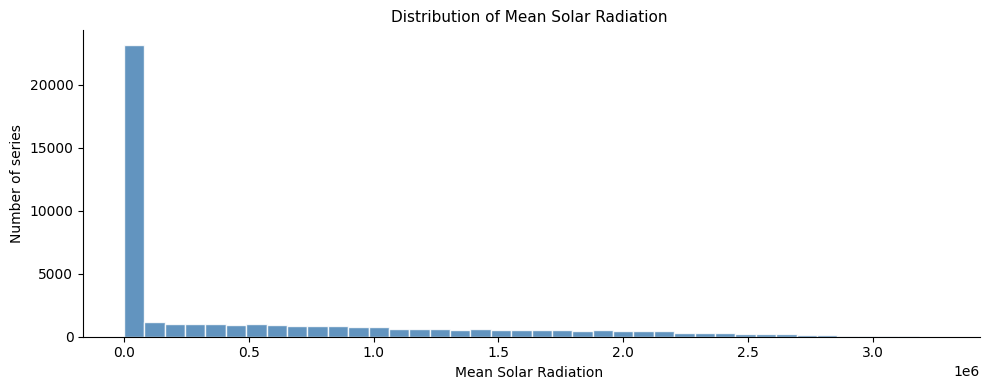

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


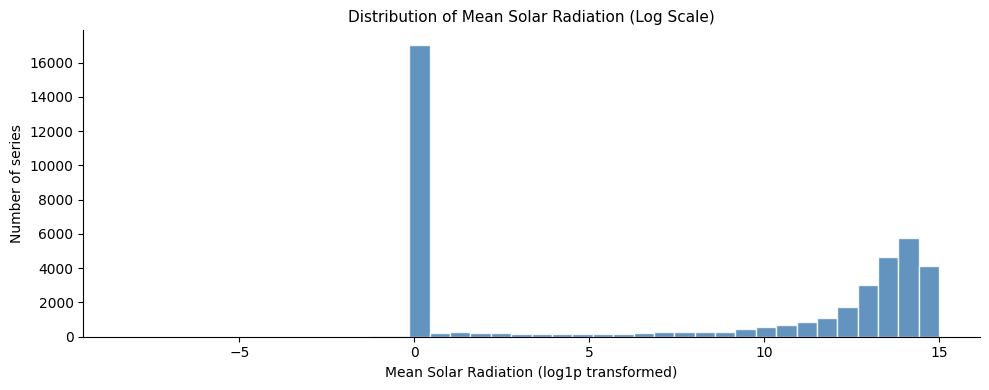

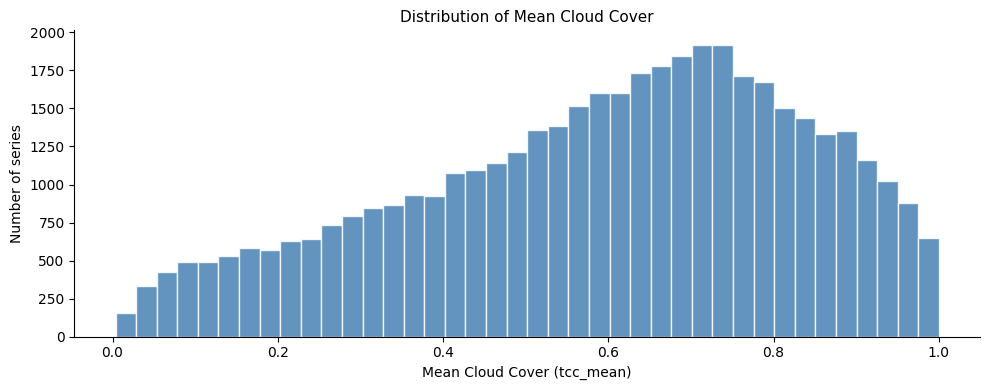

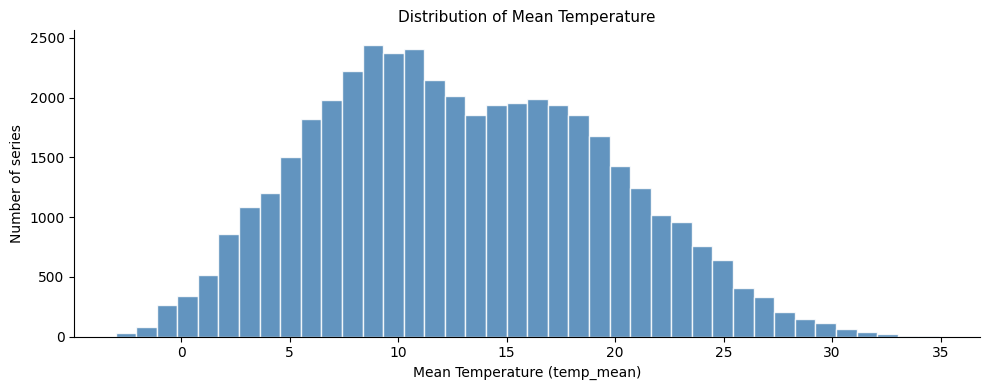

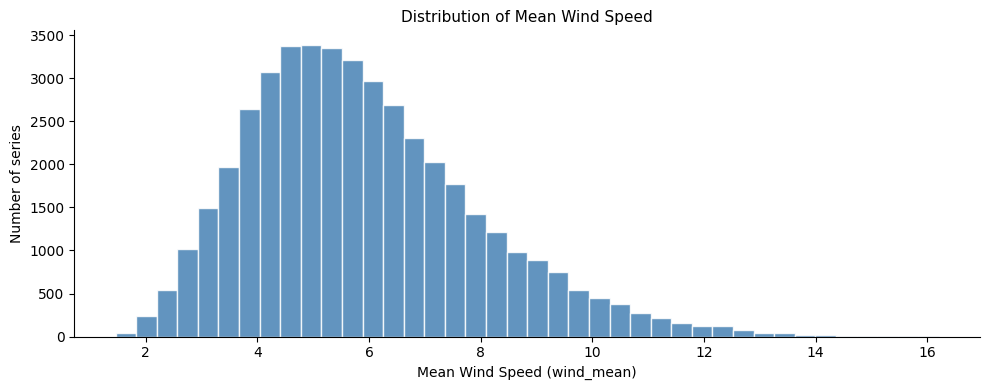

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of Mean Wind Speed'}, xlabel='Mean Wind Speed (wind_mean)', ylabel='Number of series'>)

In [73]:
# Plot histograms for ssrd_mean (with logarithmic scale)
plot_histogram(weather_flat['ssrd_mean'], title='Distribution of Mean Solar Radiation ', xlabel='Mean Solar Radiation ')
plot_histogram(np.log1p(weather_flat['ssrd_mean']), title='Distribution of Mean Solar Radiation (Log Scale)', xlabel='Mean Solar Radiation (log1p transformed)')
#plot_histogram(weather_flat['ssrd_std'], title='Distribution of Std Dev Solar Radiation', xlabel='Std Dev Solar Radiation (ssrd_std)')

# Plot histograms for tcc_mean and tcc_std
plot_histogram(weather_flat['tcc_mean'], title='Distribution of Mean Cloud Cover', xlabel='Mean Cloud Cover (tcc_mean)')
#plot_histogram(weather_flat['tcc_std'], title='Distribution of Std Dev Cloud Cover', xlabel='Std Dev Cloud Cover (tcc_std)')

# Plot histograms for temp_mean and temp_std
plot_histogram(weather_flat['temp_mean'], title='Distribution of Mean Temperature', xlabel='Mean Temperature (temp_mean)')
#plot_histogram(weather_flat['temp_std'], title='Distribution of Std Dev Temperature', xlabel='Std Dev Temperature (temp_std)')

# Plot histograms for wind_mean and wind_std
plot_histogram(weather_flat['wind_mean'], title='Distribution of Mean Wind Speed', xlabel='Mean Wind Speed (wind_mean)')
#plot_histogram(weather_flat['wind_std'], title='Distribution of Std Dev Wind Speed', xlabel='Std Dev Wind Speed (wind_std)')

Applied the log1p transformation to ssrd_mean likely to handle its skewed distribution, reduce the impact of outliers, and potentially linearize its relationship with other variables or the target variable.

In [76]:
weather_flat['log_ssrd_mean']=np.log1p(weather_flat['ssrd_mean'])
weather_flat['log_ssrd_std']=np.log1p(weather_flat['ssrd_std'])

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Boxplots for Outlier Detection

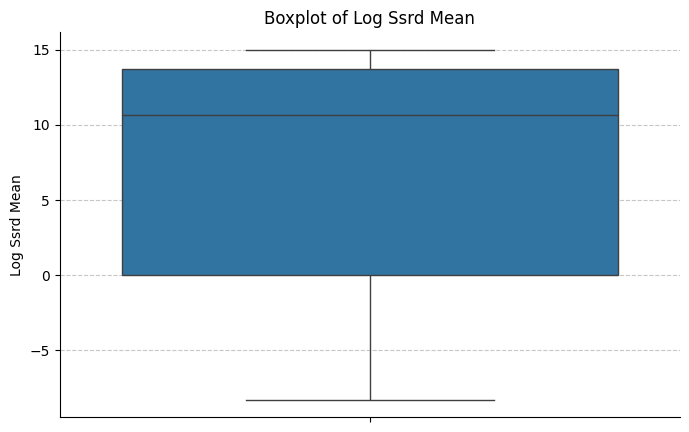

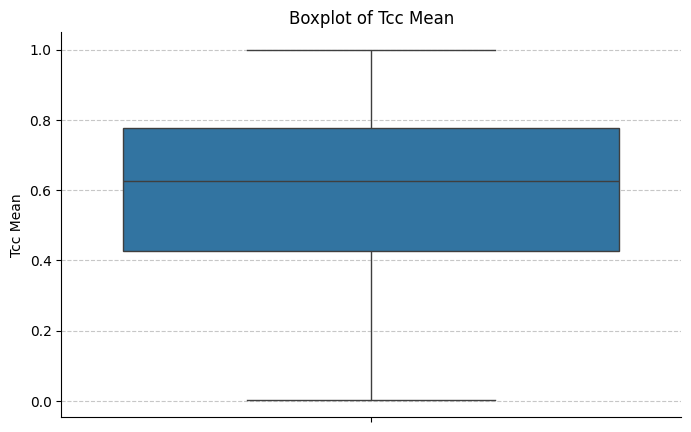

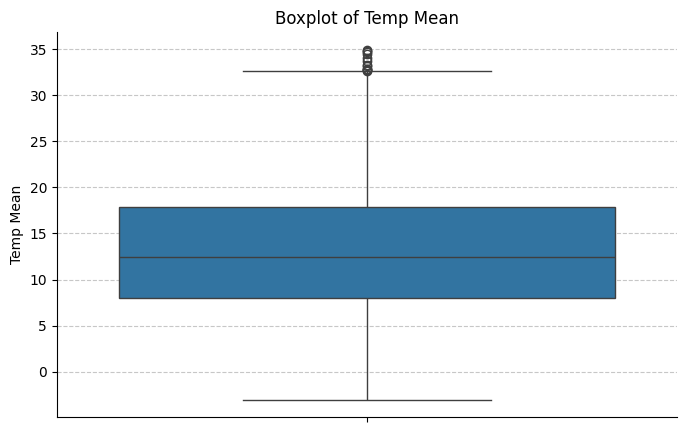

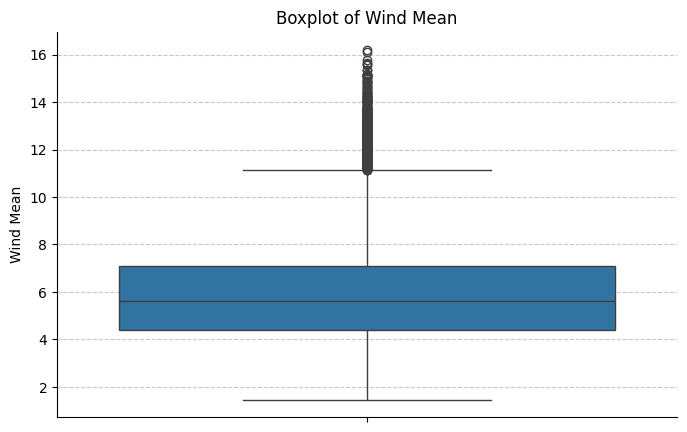

In [64]:
mean_variables = ['log_ssrd_mean', 'tcc_mean', 'temp_mean', 'wind_mean']

for col in mean_variables:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=weather_flat[col])
    plt.title(f'Boxplot of {col.replace("_", " ").title()}')
    plt.ylabel(col.replace("_", " ").title())
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Outliers in wind and temperature that might exist due to wrong measurement or exteme condition

Time Series Trends of Weather Variables

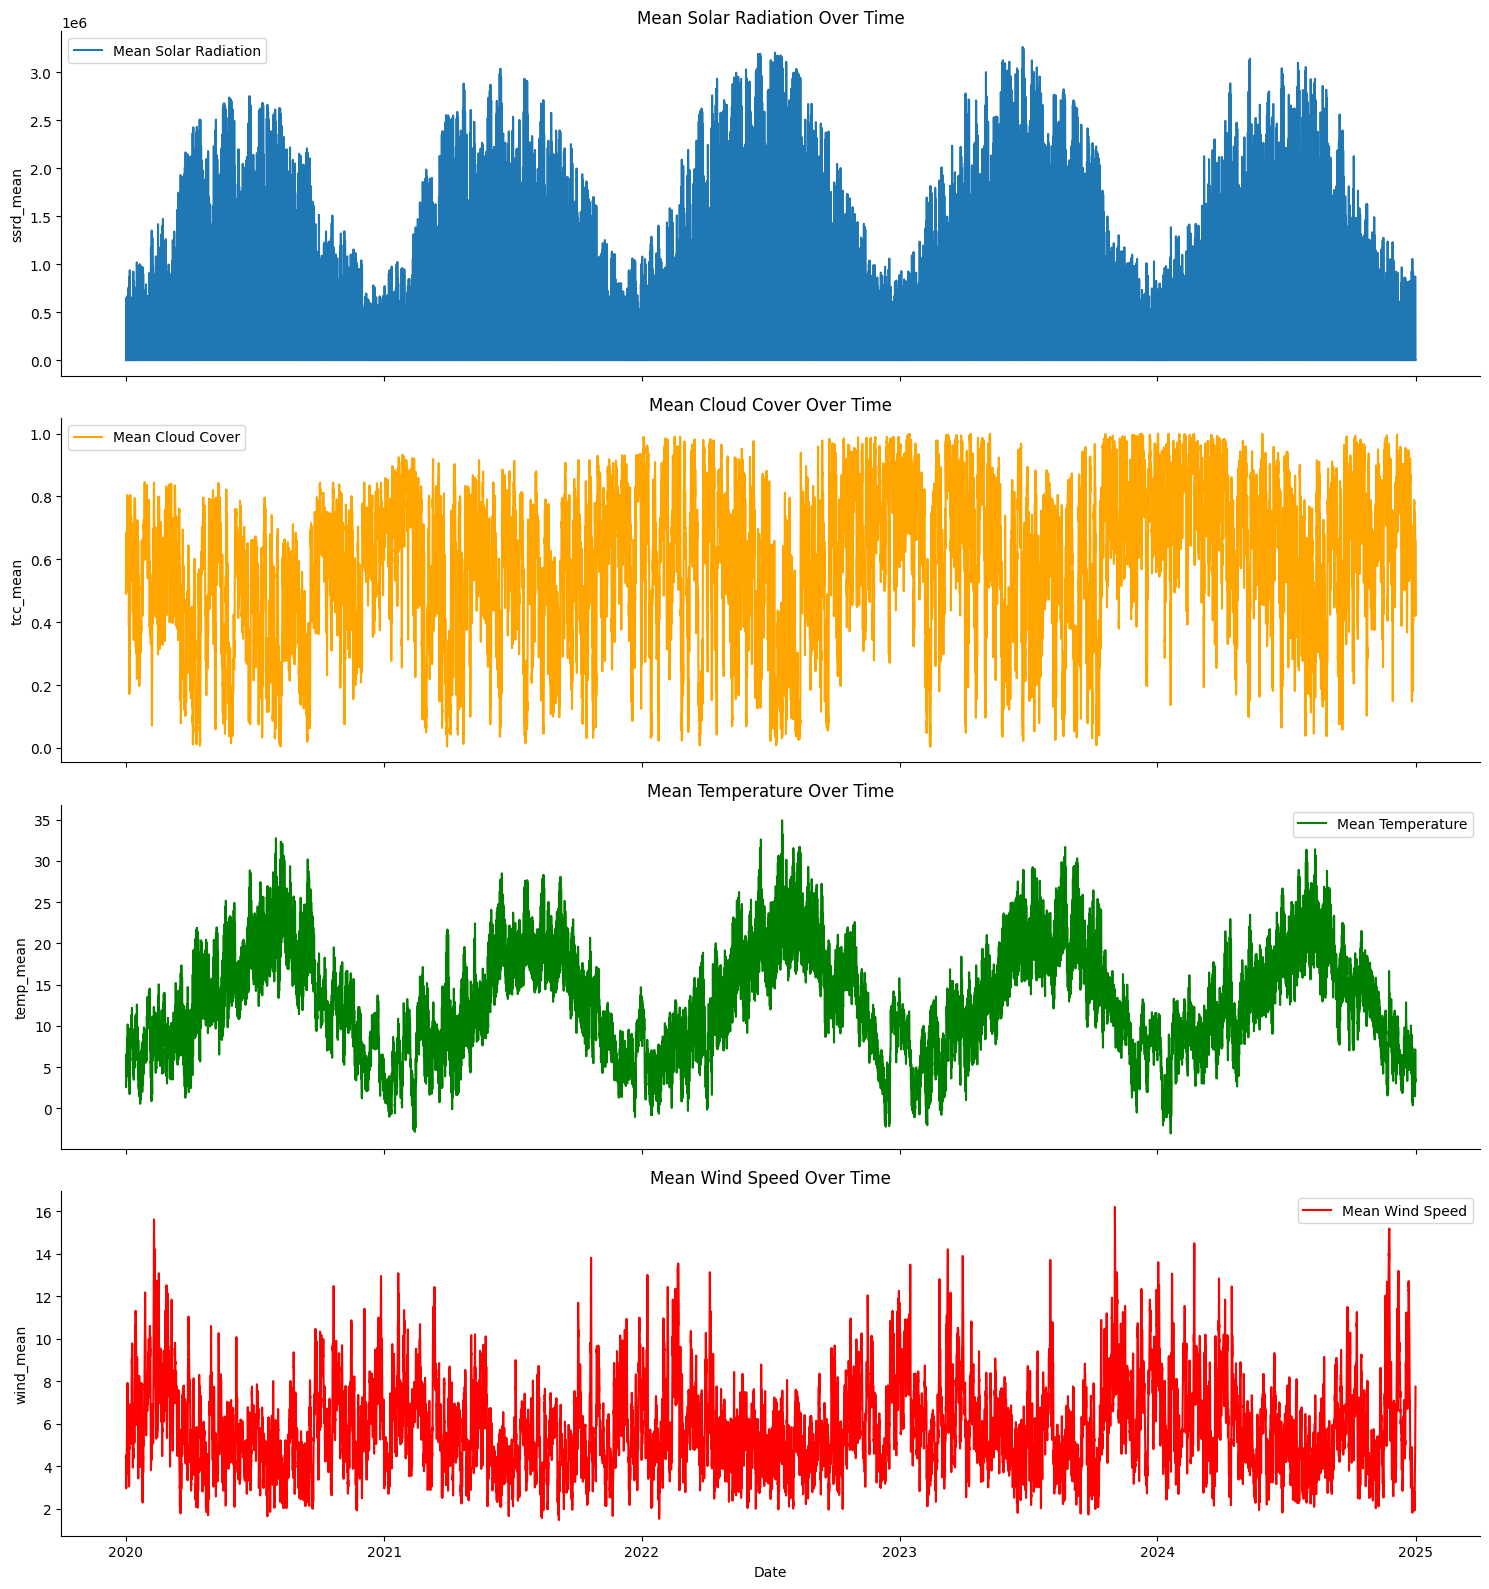

In [82]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(15, 16), sharex=True)

axes[0].plot(weather_flat['ds'], weather_flat['ssrd_mean'], label='Mean Solar Radiation')
axes[0].set_title('Mean Solar Radiation Over Time')
axes[0].set_ylabel('ssrd_mean')
axes[0].legend()

axes[1].plot(weather_flat['ds'], weather_flat['tcc_mean'], label='Mean Cloud Cover', color='orange')
axes[1].set_title('Mean Cloud Cover Over Time')
axes[1].set_ylabel('tcc_mean')
axes[1].legend()

axes[2].plot(weather_flat['ds'], weather_flat['temp_mean'], label='Mean Temperature', color='green')
axes[2].set_title('Mean Temperature Over Time')
axes[2].set_ylabel('temp_mean')
axes[2].legend()

axes[3].plot(weather_flat['ds'], weather_flat['wind_mean'], label='Mean Wind Speed', color='red')
axes[3].set_title('Mean Wind Speed Over Time')
axes[3].set_xlabel('Date')
axes[3].set_ylabel('wind_mean')
axes[3].legend()

plt.tight_layout()
plt.show()

### Bivariate Analysis

Correlation Matrix of Weather Variables

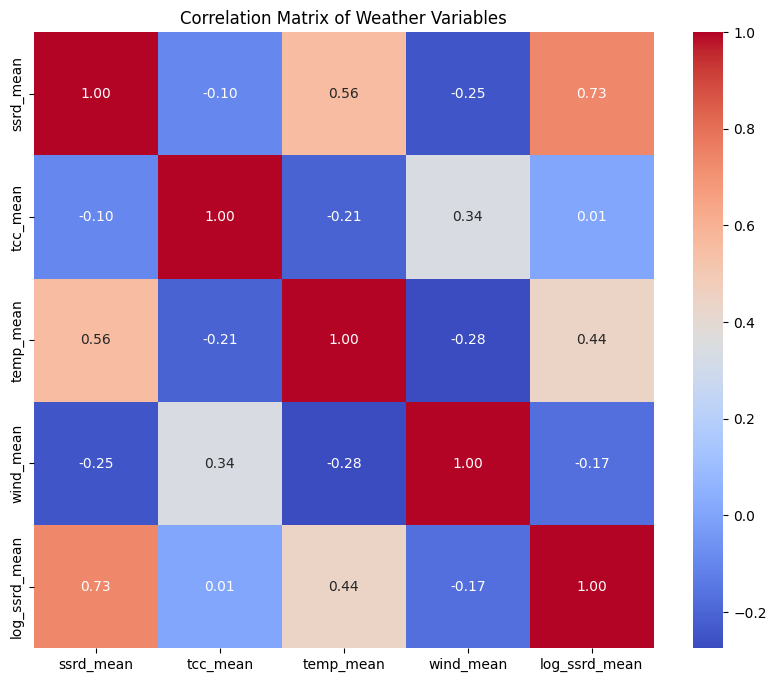

In [67]:
plt.figure(figsize=(10, 8))
mean_cols = [col for col in weather_flat.columns if '_mean' in col]
sns.heatmap(weather_flat[mean_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Weather Variables')
plt.show()

Positive correlation between ssrd_mean (solar radiation) and temp_mean (temperature). Small negative correlation between ssrd_mean (solar radiation) and tcc_mean (total cloud cover)
Positive correlation between wind and cloud.
Negative correlation between wind and ssrd

In [71]:
print("Correlation between Mean and Standard Deviation for each Weather Variable:")
print(f"Solar Radiation (ssrd): {weather_flat['ssrd_mean'].corr(weather_flat['ssrd_std']):.4f}")
print(f"Cloud Cover (tcc): {weather_flat['tcc_mean'].corr(weather_flat['tcc_std']):.4f}")
print(f"Temperature (temp): {weather_flat['temp_mean'].corr(weather_flat['temp_std']):.4f}")
print(f"Wind Speed (wind): {weather_flat['wind_mean'].corr(weather_flat['wind_std']):.4f}")

Correlation between Mean and Standard Deviation for each Weather Variable:
Solar Radiation (ssrd): 0.8498
Cloud Cover (tcc): -0.2258
Temperature (temp): 0.0205
Wind Speed (wind): 0.7391


Solar Radiation:  Strong tendency for high mean solar radiation to coincide with high variability in solar radiation across tiles. In simpler terms, on very sunny days (high mean ssrd), there's often a greater spread or difference in how much solar radiation each tile receives

Cloud Cover:  Suggests a slight inverse relationship. When the mean cloud cover is higher, the variability in cloud cover across tiles tends to be slightly lower. This might imply that on heavily overcast days, cloud cover is more uniform across the region, whereas on partly cloudy days (lower mean tcc), the patchiness of clouds leads to greater variability between tiles.

Temperature: This value is very close to zero, indicating almost no linear relationship between the mean temperature and its variability across tiles. This means the spread of temperatures across different locations doesn't significantly increase or decrease with the overall average temperature.

Wind Speed:
A strong positive correlation here suggests that when the mean wind speed is high, the variability in wind speed across tiles is also high. This could be because higher wind conditions lead to more localized turbulence or varied wind patterns influenced by topography across the region.


### Bivariate Analysis: Daily Patterns

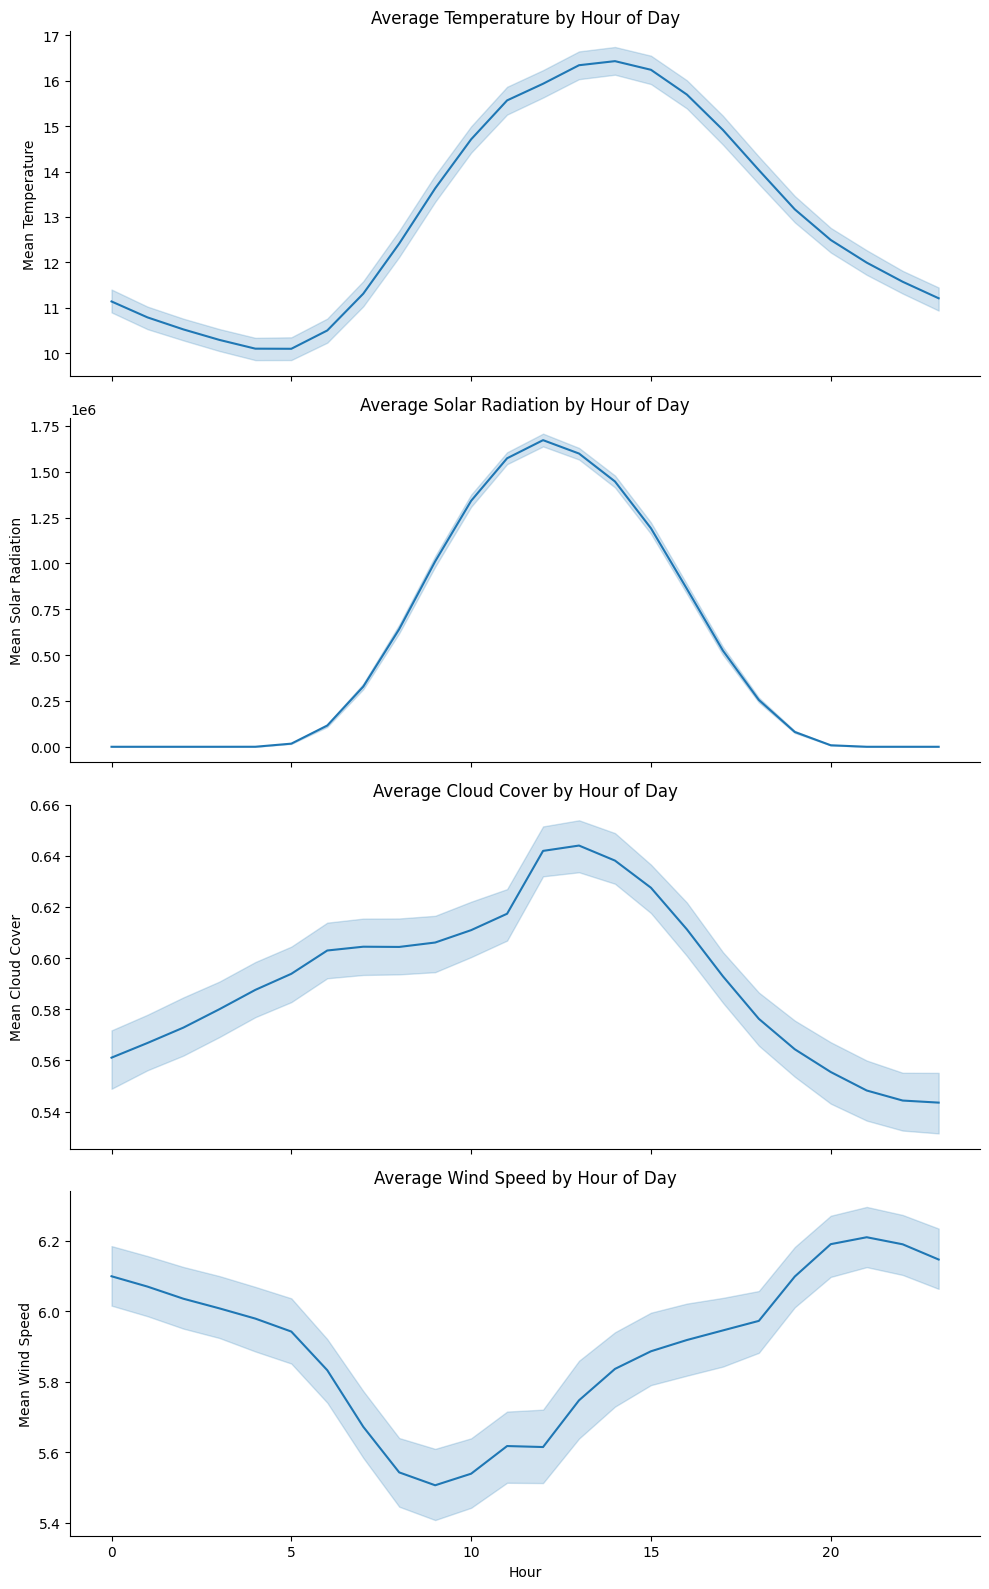

In [77]:
weather_flat['hour'] = weather_flat['ds'].dt.hour
weather_flat['day_of_week'] = weather_flat['ds'].dt.dayofweek

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 16), sharex=True) # Changed ncols to 1 and adjusted figsize

sns.lineplot(x='hour', y='temp_mean', data=weather_flat, ax=axes[0]) # Adjusted axis indexing
axes[0].set_title('Average Temperature by Hour of Day')
axes[0].set_ylabel('Mean Temperature')

sns.lineplot(x='hour', y='ssrd_mean', data=weather_flat, ax=axes[1]) # Adjusted axis indexing
axes[1].set_title('Average Solar Radiation by Hour of Day')
axes[1].set_ylabel('Mean Solar Radiation')

sns.lineplot(x='hour', y='tcc_mean', data=weather_flat, ax=axes[2]) # Adjusted axis indexing
axes[2].set_title('Average Cloud Cover by Hour of Day')
axes[2].set_ylabel('Mean Cloud Cover')

sns.lineplot(x='hour', y='wind_mean', data=weather_flat, ax=axes[3]) # Adjusted axis indexing
axes[3].set_title('Average Wind Speed by Hour of Day')
axes[3].set_xlabel('Hour') # Added x-label for the last plot
axes[3].set_ylabel('Mean Wind Speed')

plt.tight_layout()
plt.show()

### Monthly Patterns of Weather Variables

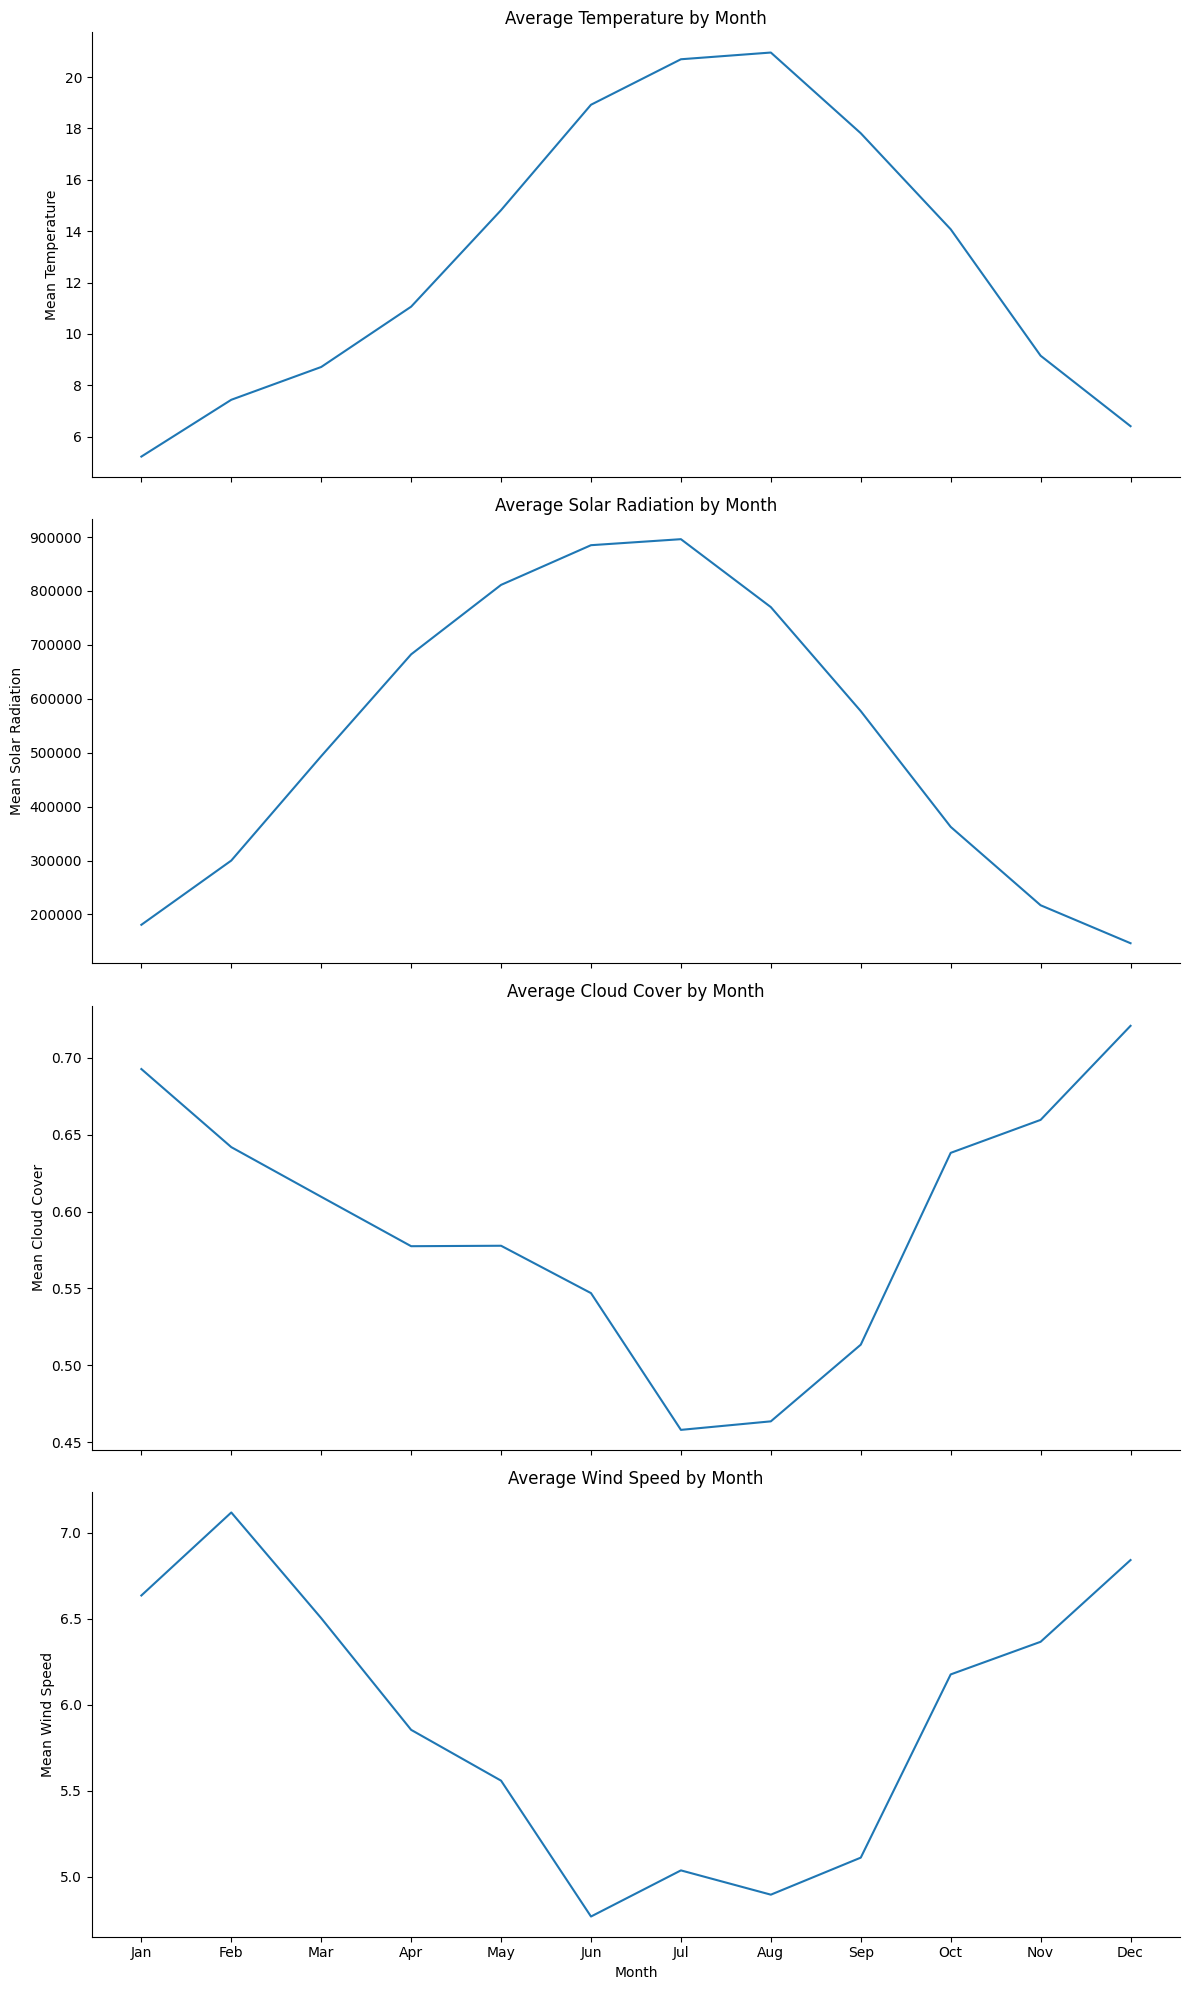

In [69]:
weather_flat['month'] = weather_flat['ds'].dt.month

monthly_avg_weather = weather_flat.groupby('month')[['temp_mean', 'ssrd_mean', 'tcc_mean', 'wind_mean']].mean().reset_index()

fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(12, 20), sharex=True)

sns.lineplot(x='month', y='temp_mean', data=monthly_avg_weather, ax=axes[0])
axes[0].set_title('Average Temperature by Month')
axes[0].set_ylabel('Mean Temperature')

sns.lineplot(x='month', y='ssrd_mean', data=monthly_avg_weather, ax=axes[1])
axes[1].set_title('Average Solar Radiation by Month')
axes[1].set_ylabel('Mean Solar Radiation')

sns.lineplot(x='month', y='tcc_mean', data=monthly_avg_weather, ax=axes[2])
axes[2].set_title('Average Cloud Cover by Month')
axes[2].set_ylabel('Mean Cloud Cover')

sns.lineplot(x='month', y='wind_mean', data=monthly_avg_weather, ax=axes[3])
axes[3].set_title('Average Wind Speed by Month')
axes[3].set_xlabel('Month')
axes[3].set_ylabel('Mean Wind Speed')

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(ticks=range(1, 13), labels=month_labels)

plt.tight_layout()
plt.show()